# External KneeMRI evaluation

This notebook uses a frozen MRNet-trained checkpoint. No training or threshold adjustment occurs. Partial or complete ACL injury is the primary positive class. Other findings have no reference labels. Repeated series are grouped by exam ID; patient independence is unverified. Input is full sagittal volume without ROI cropping.

In [1]:
from pathlib import Path
import sys,json
ROOT=Path.cwd()
if not (ROOT/'config.yaml').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from src.utils import config
cfg=config()
out=ROOT/cfg['external_kneemri']['results']
print(json.loads((out/'protocol.json').read_text()))

{'checkpoint_sha256': 'b60293f6c7130fd646c81b6d758584faf3e17b2689503b5278ad711156d546da', 'targets': ['acl'], 'threshold_source': 'Reserved MRNet calibration partition (100 studies); locked before external evaluation', 'primary_mapping': '0 healthy ACL; 1 or 2 ACL injury', 'unit': 'examId; mean score across repeated series; maximum severity', 'secondary': 'complete rupture vs healthy, excluding partial injuries', 'input': 'full sagittal volumes; no ROI crop; missing axial and coronal planes', 'patient_independence': 'not established by examId alone', 'no_training': True}


In [2]:
print(json.loads((out/'status.json').read_text()))
if (out/'metrics.json').exists():
    display(json.loads((out/'metrics.json').read_text()))
else:
    print('Evaluation is still running; no final performance claim is available.')

{'state': 'complete', 'completed': 917, 'total': 917}


{'primary': {'acl': {'auroc': 0.6029749024993846,
   'average_precision': 0.3167935456089418,
   'f1': 0.39178515007898895,
   'sensitivity': 0.5486725663716814,
   'specificity': 0.5856515373352855,
   'precision': 0.3046683046683047,
   'accuracy': 0.5764576457645765,
   'threshold': 0.24608272654141142,
   'confusion_matrix': [[400, 283], [102, 124]],
   'positive_cases': 226,
   'negative_cases': 683},
  'macro': {'auroc': 0.6029749024993846,
   'average_precision': 0.3167935456089418,
   'f1': 0.39178515007898895,
   'sensitivity': 0.5486725663716814,
   'specificity': 0.5856515373352855,
   'precision': 0.3046683046683047,
   'accuracy': 0.5764576457645765}},
 'complete_vs_healthy': {'acl': {'auroc': 0.6366298416078797,
   'average_precision': 0.11528264164763957,
   'f1': 0.1876675603217158,
   'sensitivity': 0.6363636363636364,
   'specificity': 0.5856515373352855,
   'precision': 0.11006289308176101,
   'accuracy': 0.5894308943089431,
   'threshold': 0.24608272654141142,
   'c

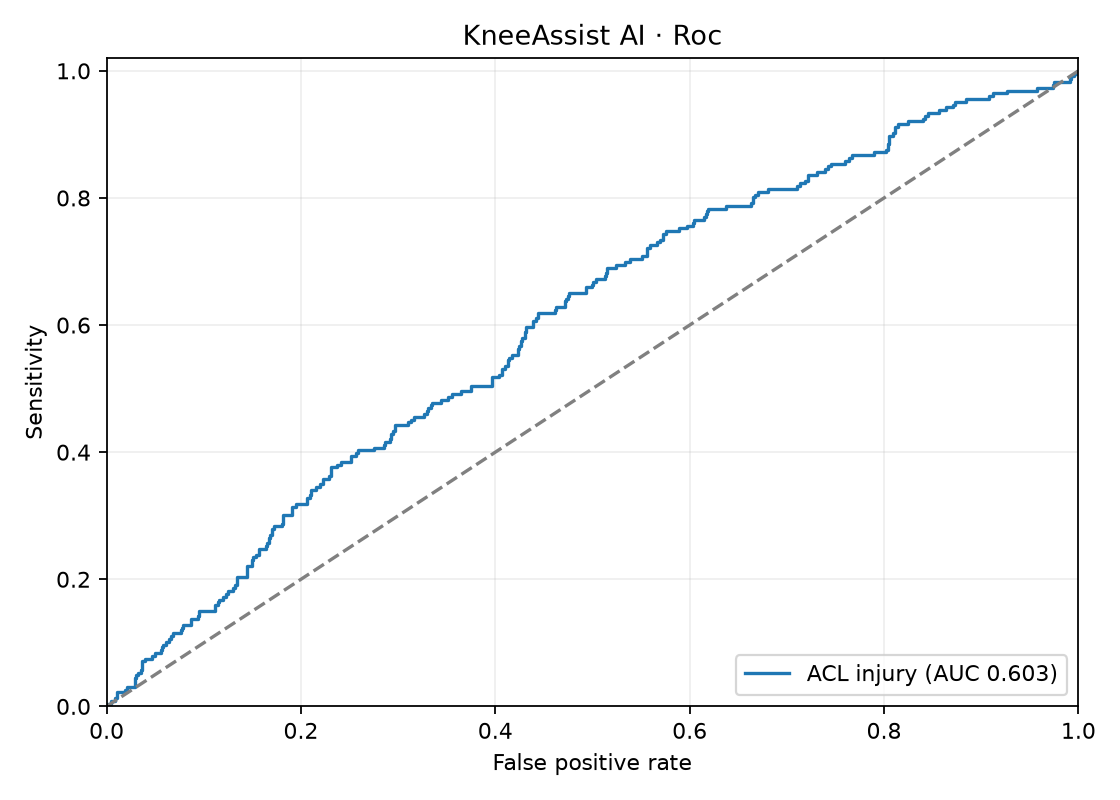

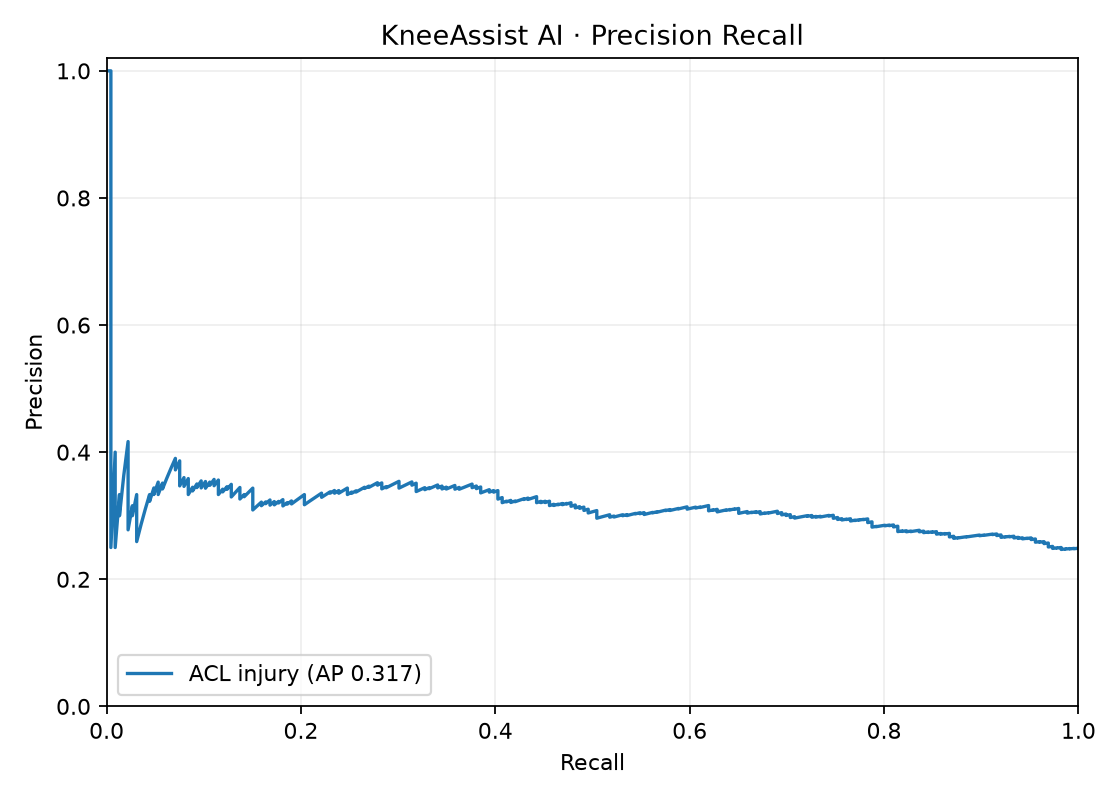

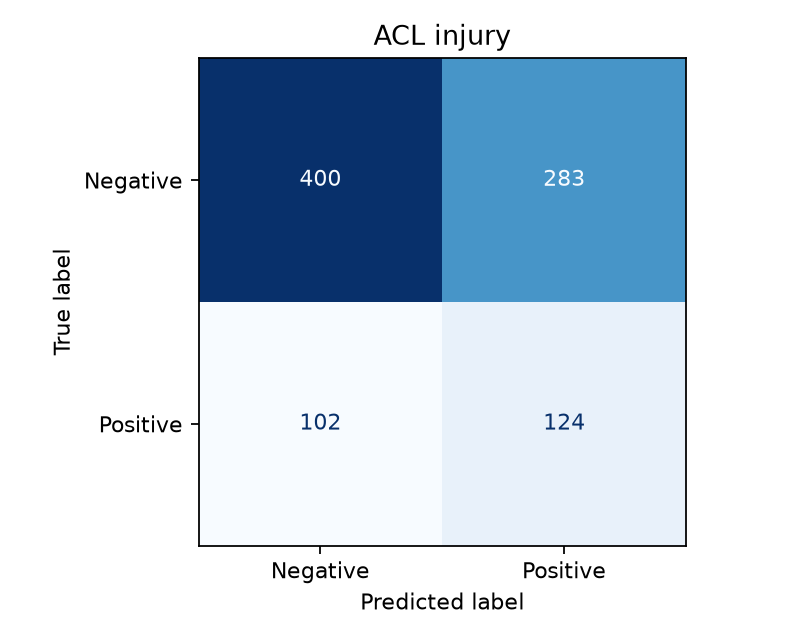

In [3]:
from IPython.display import Image,display
for name in ['roc_curves.png','precision_recall_curves.png','confusion_matrices.png']:
    p=out/name
    if p.exists(): display(Image(filename=str(p)))

## Local dashboard example
Upload `sample_cases/kneemri_external_example.zip` in the app. Missing-plane and uncalibrated-score warnings apply. Heatmaps are model attention, not confirmed lesions. The external images and converted sample must not be bundled into a public release without reviewing the dataset restrictions.